### 1. 加载数据

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sweetviz as sv
import warnings
warnings.filterwarnings('ignore')


def _irrigation_pkg_root() -> Path:
    here = Path.cwd().resolve()
    if here.name == "notebooks":
        return here.parent
    if (here / "data" / "train.csv").is_file():
        return here
    if (here / "Predicting_Irrigation_Need" / "data" / "train.csv").is_file():
        return here / "Predicting_Irrigation_Need"
    return here


_PKG = _irrigation_pkg_root()
_DATA = _PKG / "data"
train = pd.read_csv(_DATA / "train.csv")
test = pd.read_csv(_DATA / "test.csv")

print(train.shape)
print(test.shape)

print(train.head())

(630000, 21)
(270000, 20)
   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3                     0.87          13.32     61.57      1357.33   
4                     0.96          20.22     91.11      1538.20   

   Sunlight_Hours  ...  Crop_Type Crop_Growth_Stage  Season Irrigation_Type  \
0            5.90  ...  Sugarcane            Sowing    Zaid            Drip   
1            6.98  ...      Wheat        Vegetative 

### 2. 数据特征

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

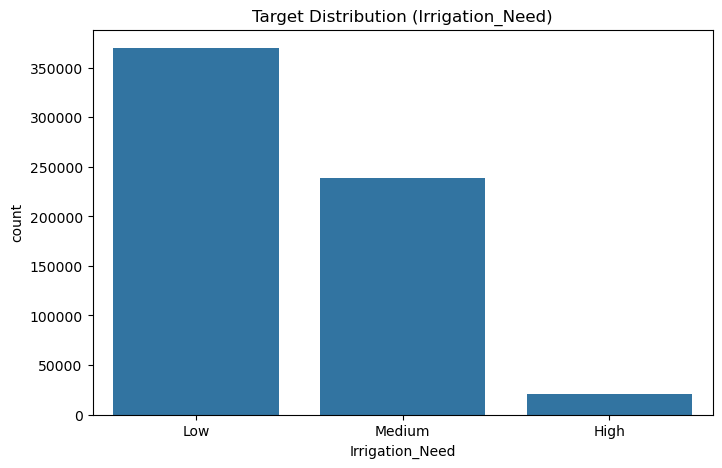

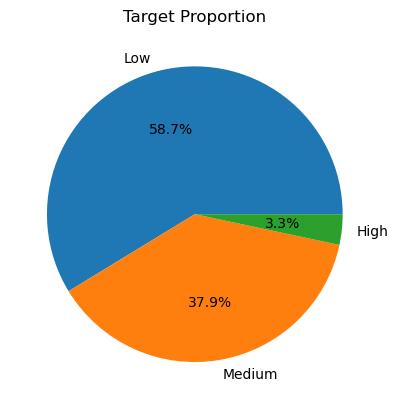

In [2]:
# 1. 数据基本信息
print(train.info())
print(train.describe())
print("\n-------describe object-------")
print(train.describe(include='object'))

# 2. 数据Target
target_counts = train['Irrigation_Need'].value_counts()
target_ratio = train['Irrigation_Need'].value_counts(normalize=True) * 100

print(target_counts)
print(target_ratio.round(2))

# 可视化
plt.figure(figsize=(8,5))
sns.countplot(data=train, x='Irrigation_Need', order=['Low', 'Medium', 'High'])
plt.title('Target Distribution (Irrigation_Need)')
plt.show()

# 或饼图
target_ratio.plot.pie(autopct='%.1f%%')
plt.title('Target Proportion')
plt.ylabel('')
plt.show()

### 3. 数值特征分析

数值特征： ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
类别特征： ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


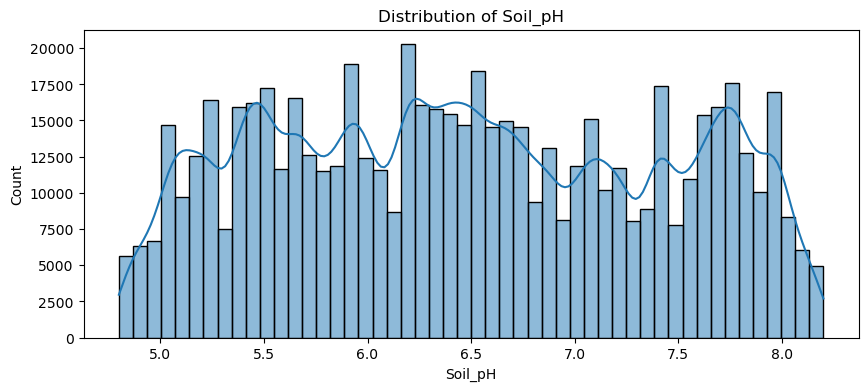

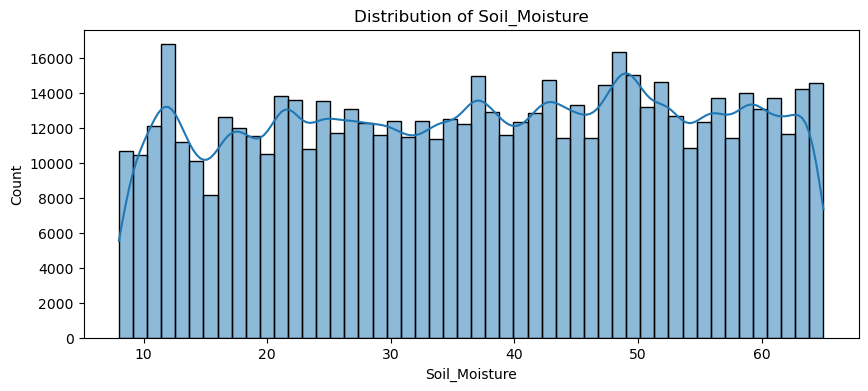

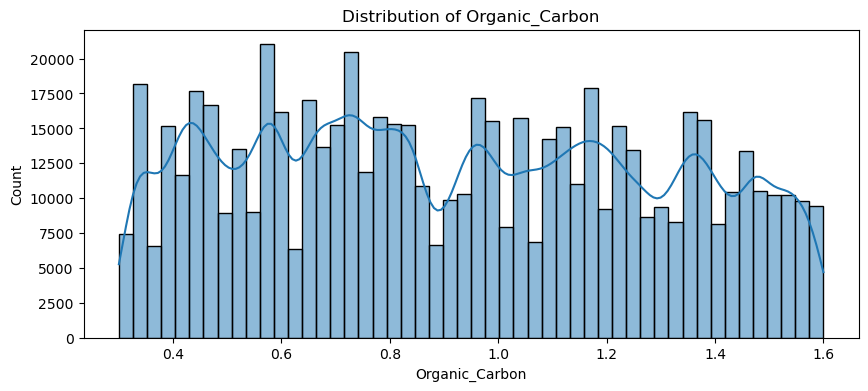

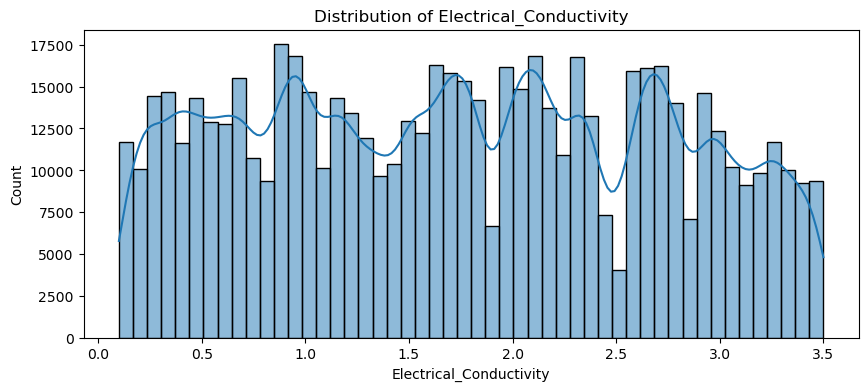

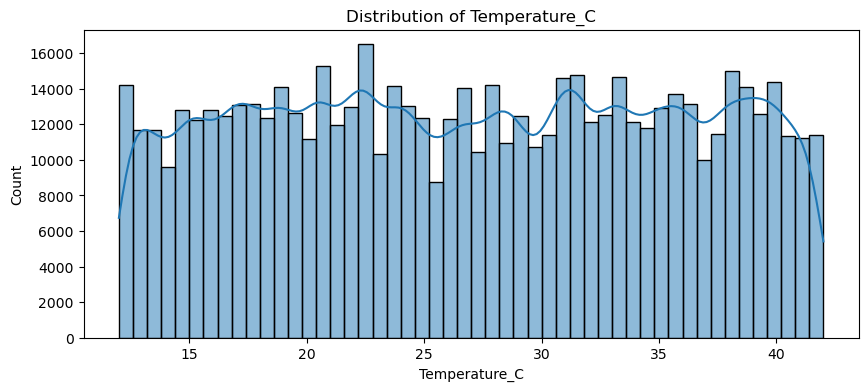

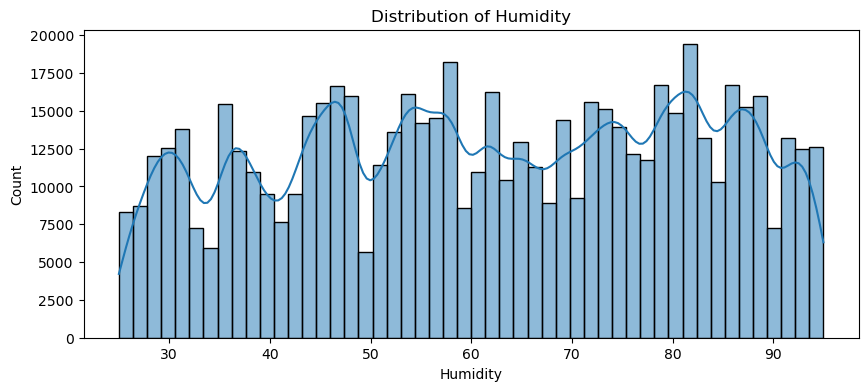

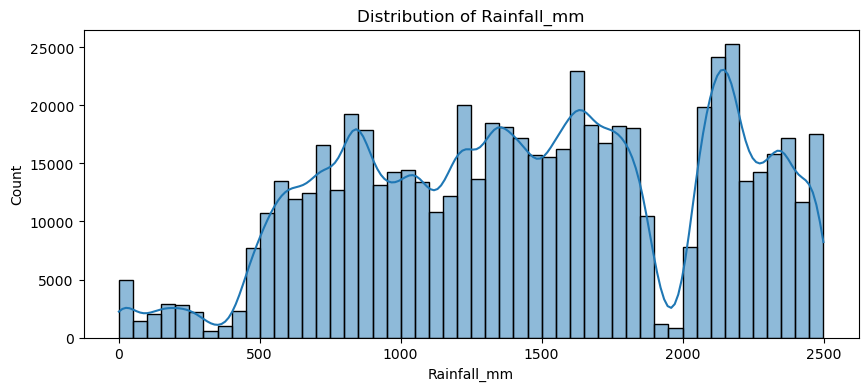

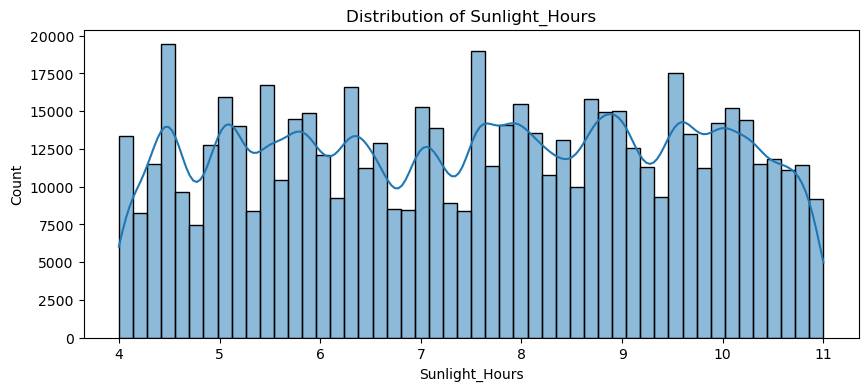

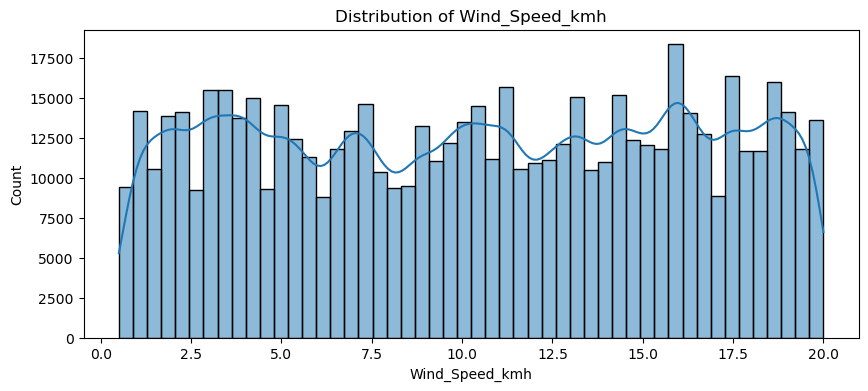

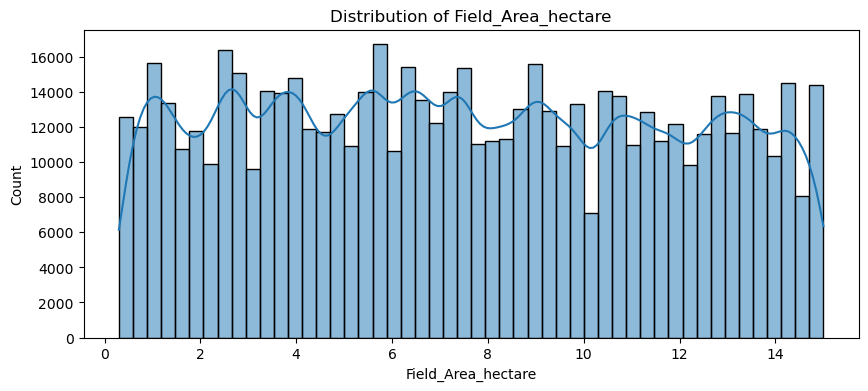

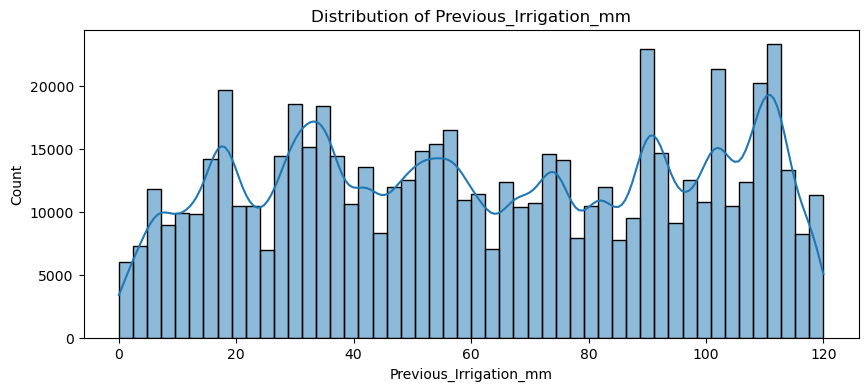

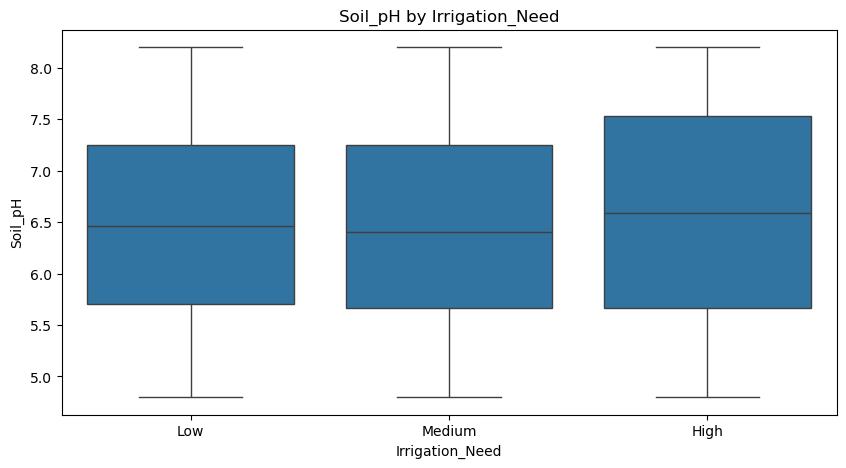

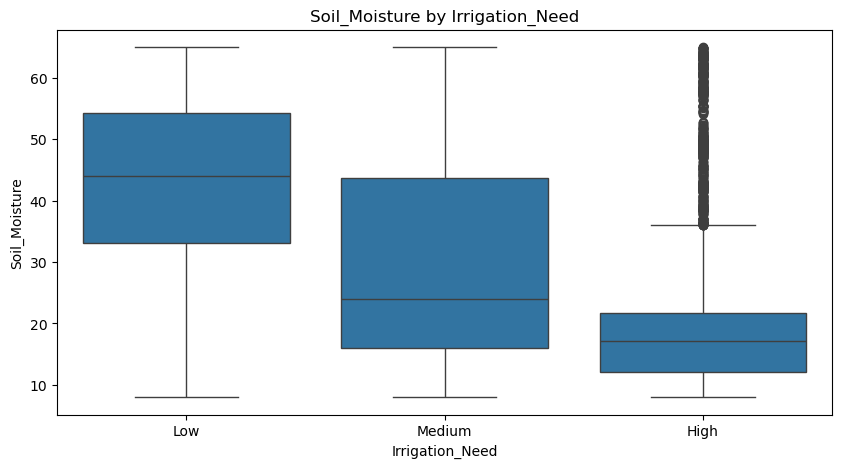

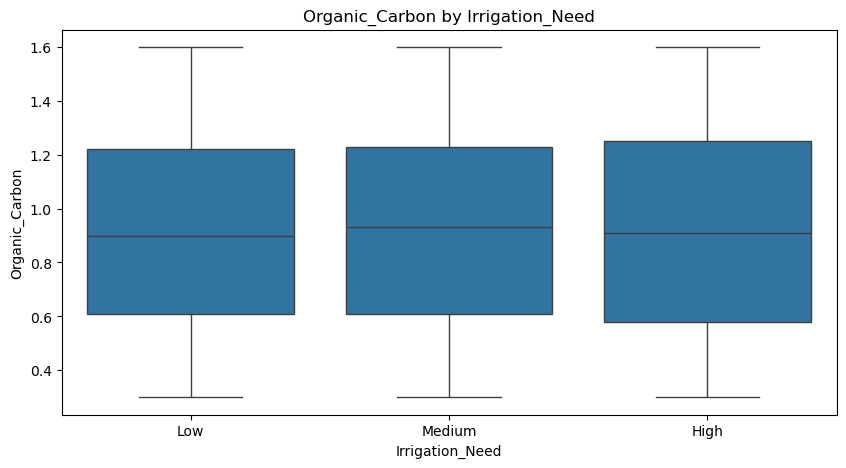

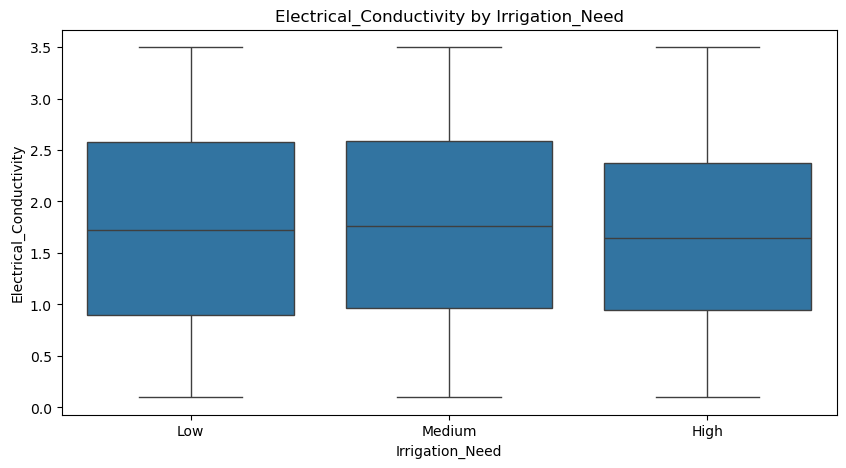

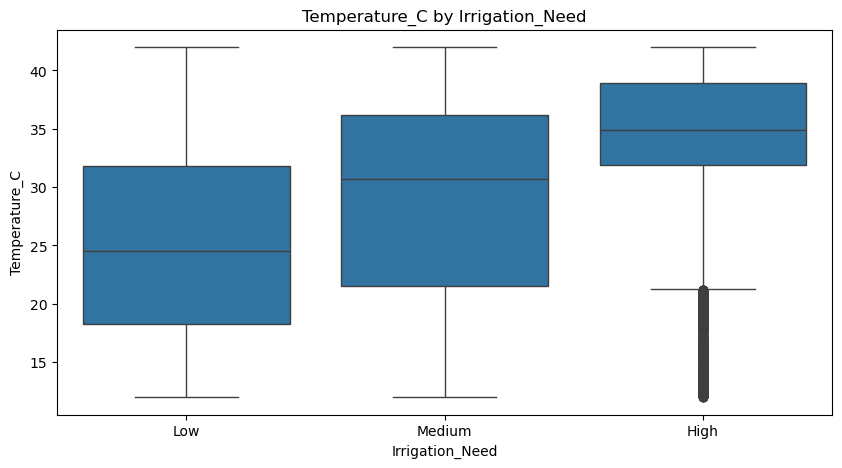

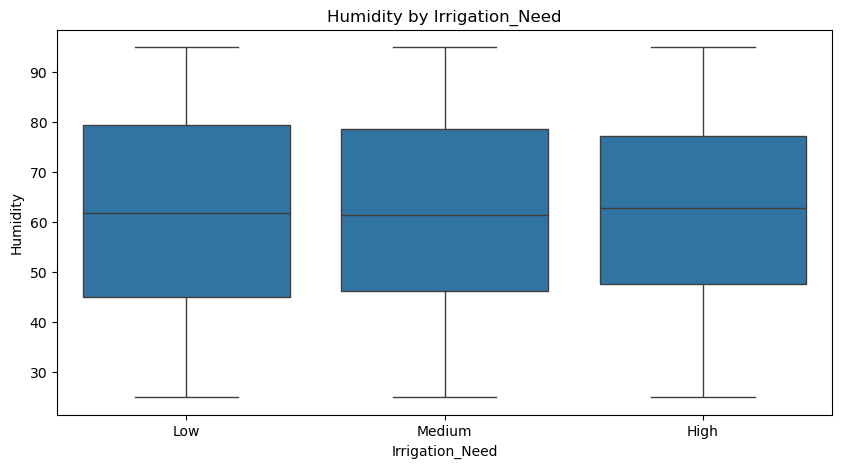

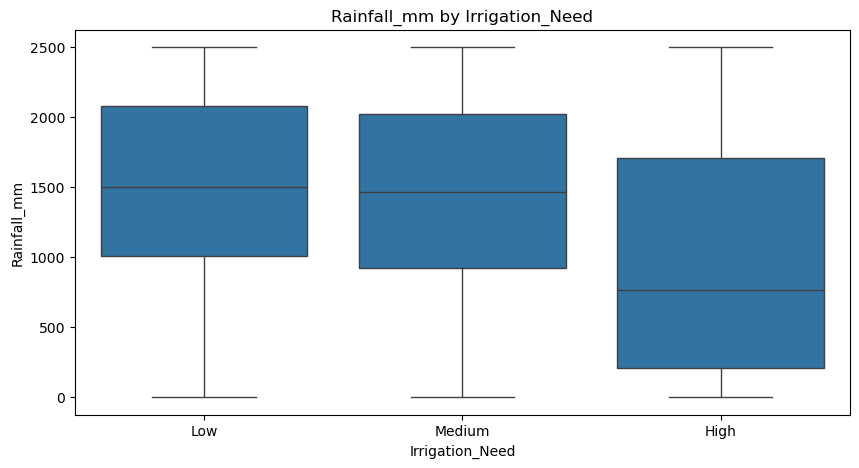

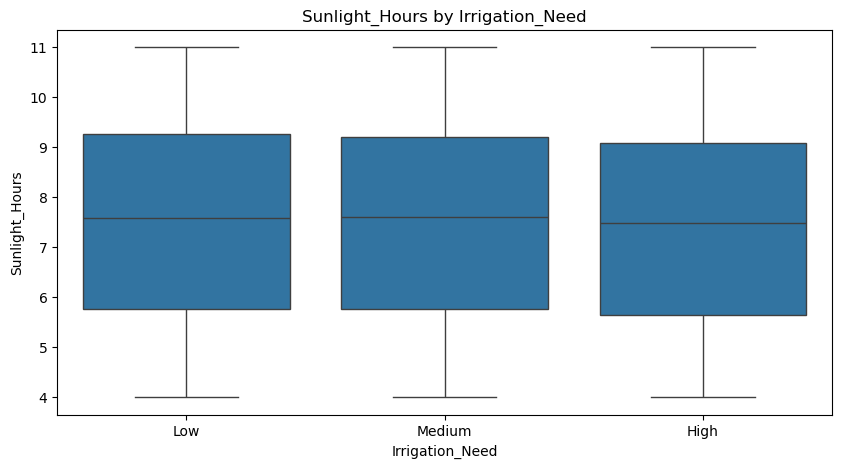

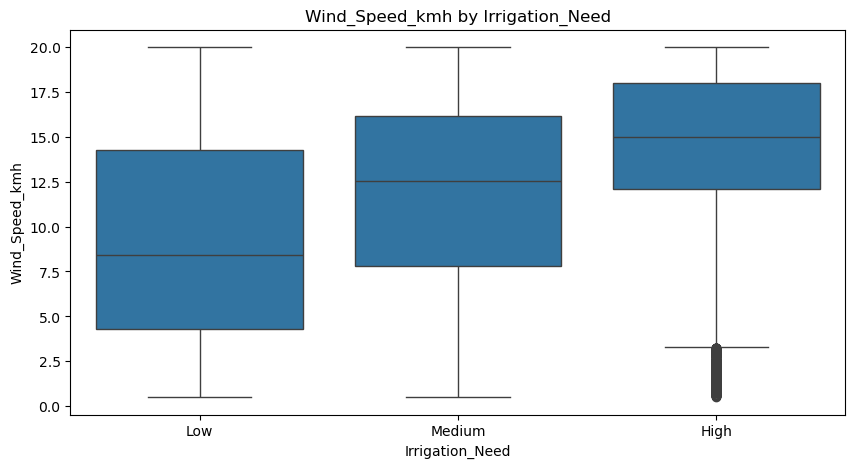

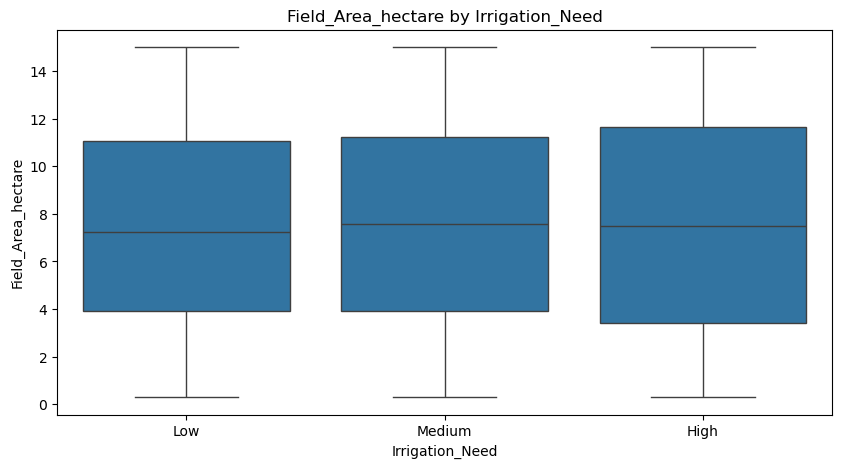

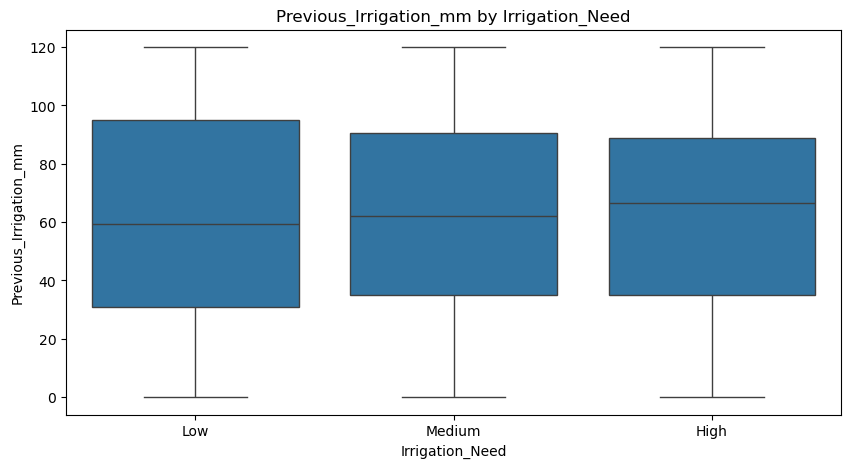

In [3]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in num_cols: num_cols.remove('id')
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
if 'Irrigation_Need' in cat_cols: cat_cols.remove('Irrigation_Need')

print("数值特征：", num_cols)
print("类别特征：", cat_cols)

# 分布（直方图 + KDE）
for col in num_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(train[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

# 箱线图（看离群点 + 与 target 的关系）
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=train, x='Irrigation_Need', y=col, order=['Low','Medium','High'])
    plt.title(f'{col} by Irrigation_Need')
    plt.show()

## 4. 相关性分析

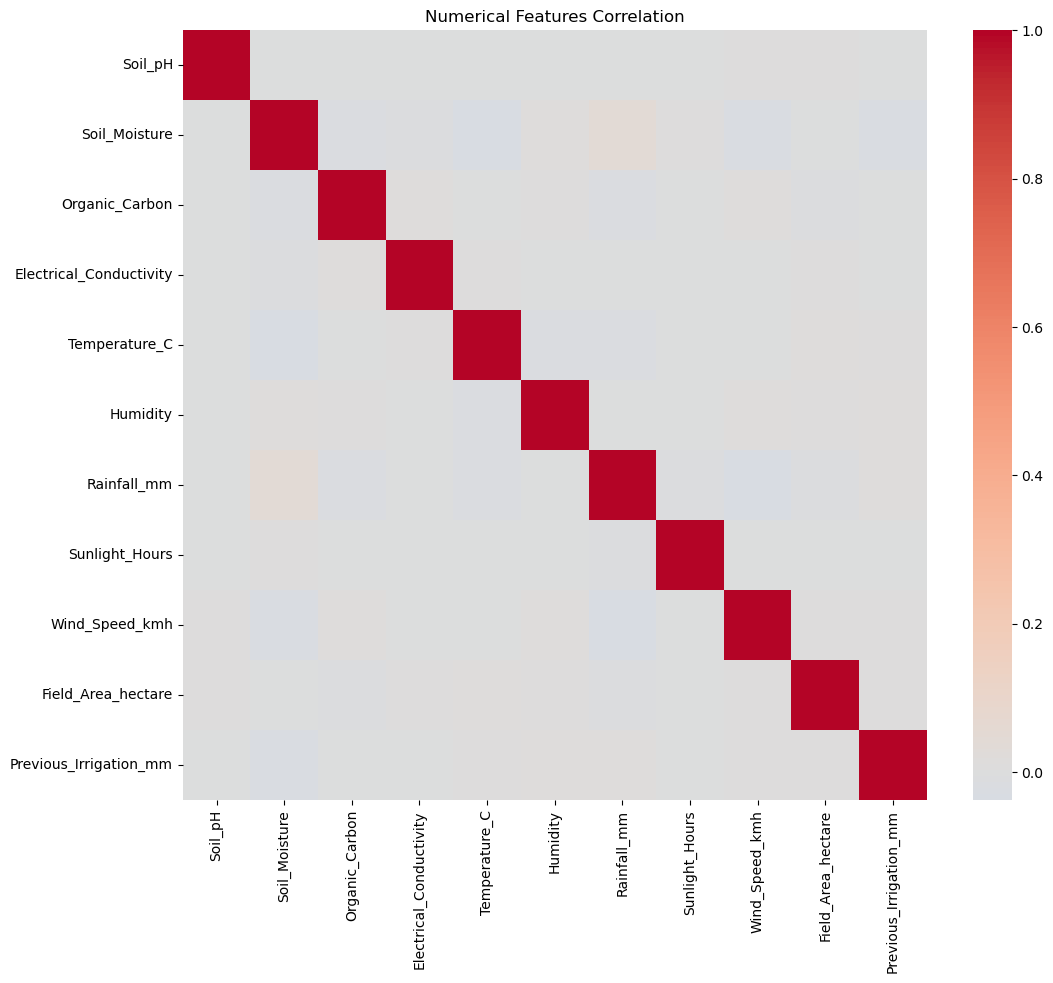

target_num                 1.000000
Wind_Speed_kmh             0.258170
Temperature_C              0.252867
Previous_Irrigation_mm     0.019637
Field_Area_hectare         0.017699
Electrical_Conductivity    0.010785
Organic_Carbon             0.006451
Soil_pH                    0.000150
Sunlight_Hours            -0.000313
Humidity                  -0.021870
Rainfall_mm               -0.111478
Soil_Moisture             -0.455482
Name: target_num, dtype: float64


In [4]:
# 数值特征相关性热图
corr = train[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Numerical Features Correlation')
plt.show()

# 选 Top 相关特征与 target 的关系（可手动编码 target）
target_map = {'Low':0, 'Medium':1, 'High':2}
train['target_num'] = train['Irrigation_Need'].map(target_map)

corr_with_target = train[num_cols + ['target_num']].corr()['target_num'].sort_values(ascending=False)
print(corr_with_target)

## 5. 类别特征分析


=== Soil_Type ===
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64
Irrigation_Need  High    Low  Medium
Soil_Type                           
Clay             3.51  58.70   37.80
Loamy            2.88  59.93   37.19
Sandy            3.87  57.63   38.50
Silt             3.03  58.68   38.29


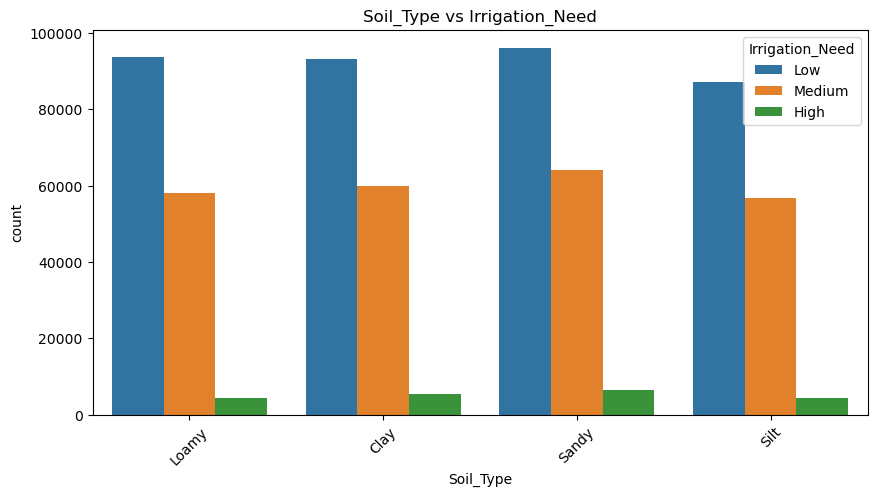


=== Crop_Type ===
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64
Irrigation_Need  High    Low  Medium
Crop_Type                           
Cotton           3.61  58.72   37.67
Maize            4.22  57.01   38.77
Potato           2.74  57.59   39.67
Rice             2.34  59.99   37.68
Sugarcane        3.92  59.29   36.80
Wheat            3.17  59.65   37.18


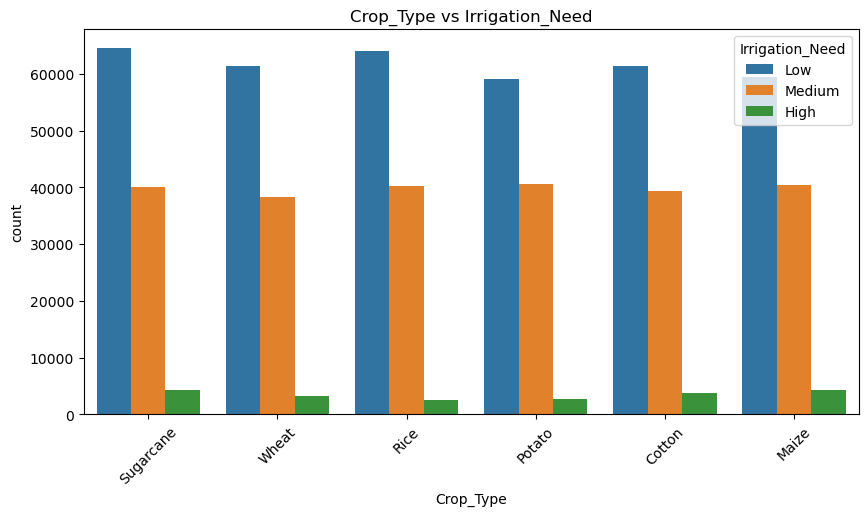


=== Crop_Growth_Stage ===
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64
Irrigation_Need    High    Low  Medium
Crop_Growth_Stage                     
Flowering          6.44  30.60   62.96
Harvest            0.32  84.79   14.89
Sowing             0.16  87.18   12.65
Vegetative         6.41  32.38   61.21


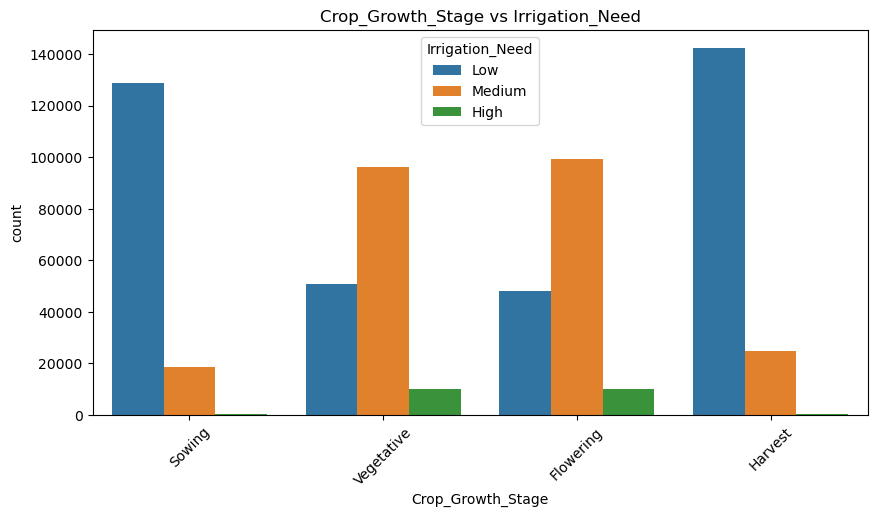


=== Season ===
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64
Irrigation_Need  High    Low  Medium
Season                              
Kharif           3.48  57.13   39.38
Rabi             3.21  59.98   36.81
Zaid             3.30  59.11   37.59


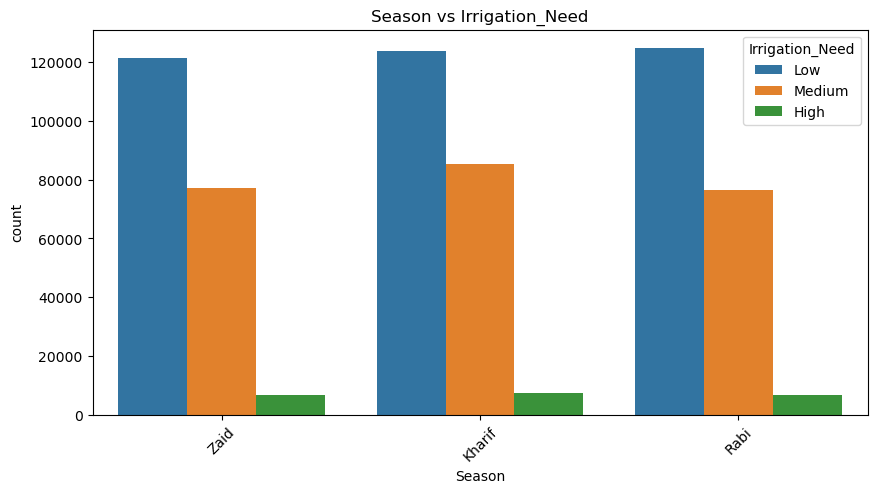


=== Irrigation_Type ===
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64
Irrigation_Need  High    Low  Medium
Irrigation_Type                     
Canal            3.82  55.80   40.39
Drip             2.67  59.46   37.87
Rainfed          3.32  60.67   36.02
Sprinkler        3.49  59.07   37.44


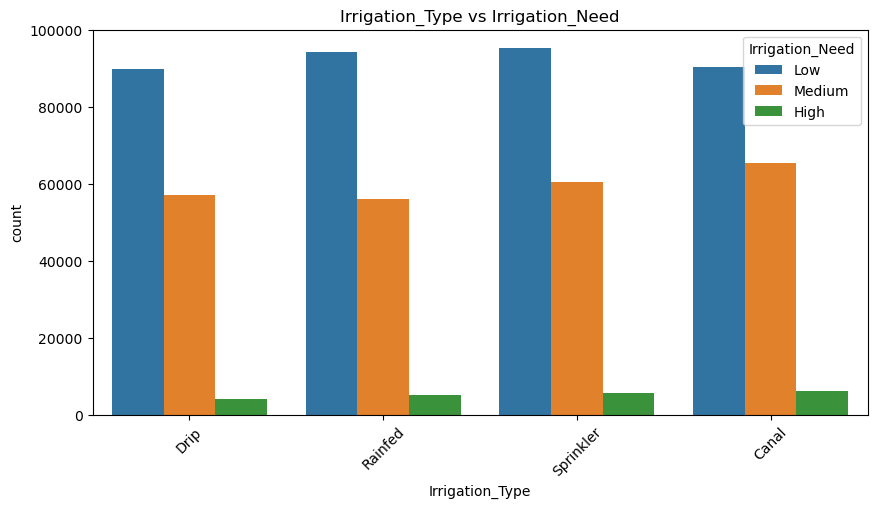


=== Water_Source ===
Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64
Irrigation_Need  High    Low  Medium
Water_Source                        
Groundwater      2.35  60.10   37.55
Rainwater        3.35  60.37   36.28
Reservoir        3.26  56.26   40.47
River            4.34  58.30   37.35


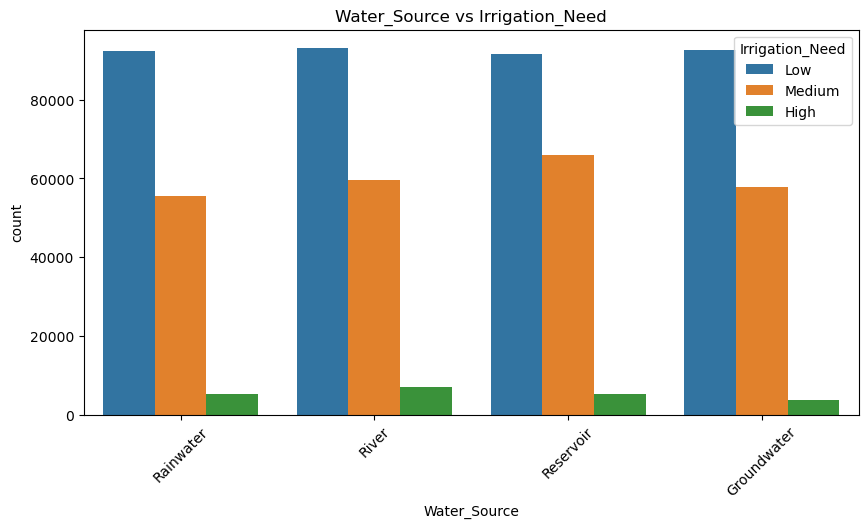


=== Mulching_Used ===
Mulching_Used
No     316453
Yes    313547
Name: count, dtype: int64
Irrigation_Need  High    Low  Medium
Mulching_Used                       
No               5.85  44.50   49.64
Yes              0.79  73.06   26.15


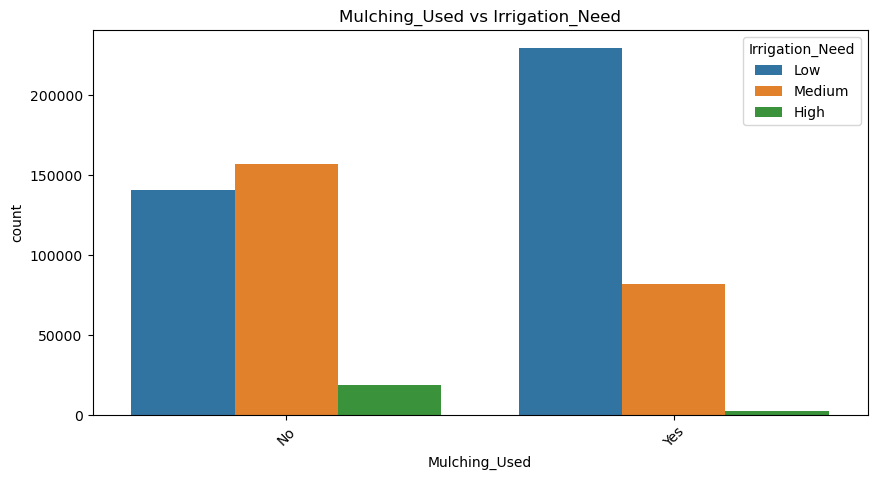


=== Region ===
Region
South      134809
West       131189
East       126163
Central    123712
North      114127
Name: count, dtype: int64
Irrigation_Need  High    Low  Medium
Region                              
Central          3.44  59.30   37.26
East             2.87  59.35   37.78
North            3.43  57.63   38.95
South            3.48  58.65   37.87
West             3.46  58.58   37.96


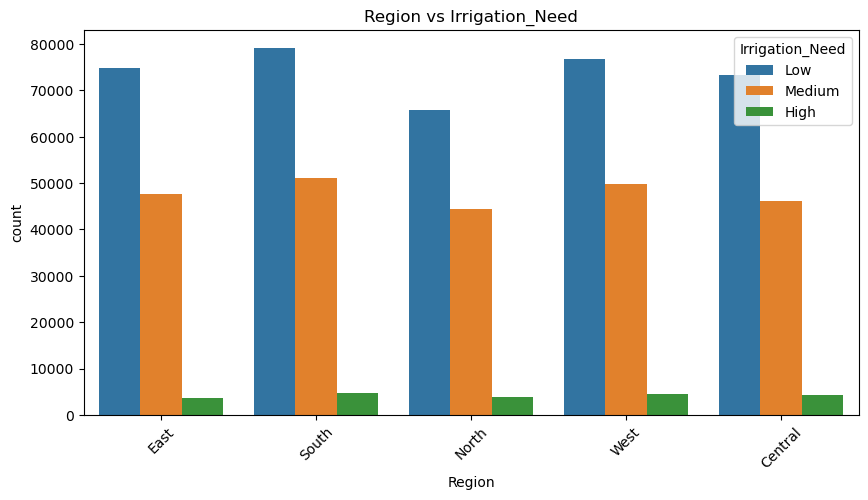

In [5]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(train[col].value_counts())
    
    # 与 target 的交叉表
    cross = pd.crosstab(train[col], train['Irrigation_Need'], normalize='index') * 100
    print(cross.round(2))
    
    # 可视化
    plt.figure(figsize=(10,5))
    sns.countplot(data=train, x=col, hue='Irrigation_Need')
    plt.title(f'{col} vs Irrigation_Need')
    plt.xticks(rotation=45)
    plt.show()

## 6. 生成自动化报告

In [6]:
from ydata_profiling import ProfileReport

profile = ProfileReport(train, title="Irrigation Need EDA Report", explorative=True, locale='zh')
profile.to_file("eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:09<00:00,  2.31it/s]


生成报告结构:   0%|          | 0/1 [00:00<?, ?it/s]

渲染HTML报告:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]